<h1>Dengue Data Analysis</h1>
<hr>
<h2>Data Analyst: Kim Andrei D. Lugatoc</h2>

<h3>Import libraries</h3>

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy.stats import f_oneway
warnings.filterwarnings('ignore')

<h3>Load dataset</h3>

In [2]:
dengue = pd.read_csv('dataset\\dengue.csv')
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [3]:
dengue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


In [4]:
dengue.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

<h1>Check if there is inconsistencies</h1>

In [5]:
dengue.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

In [6]:
dengue.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

<h1> DENGUE CASES TREND FROM 2016 - 2020 </h1>

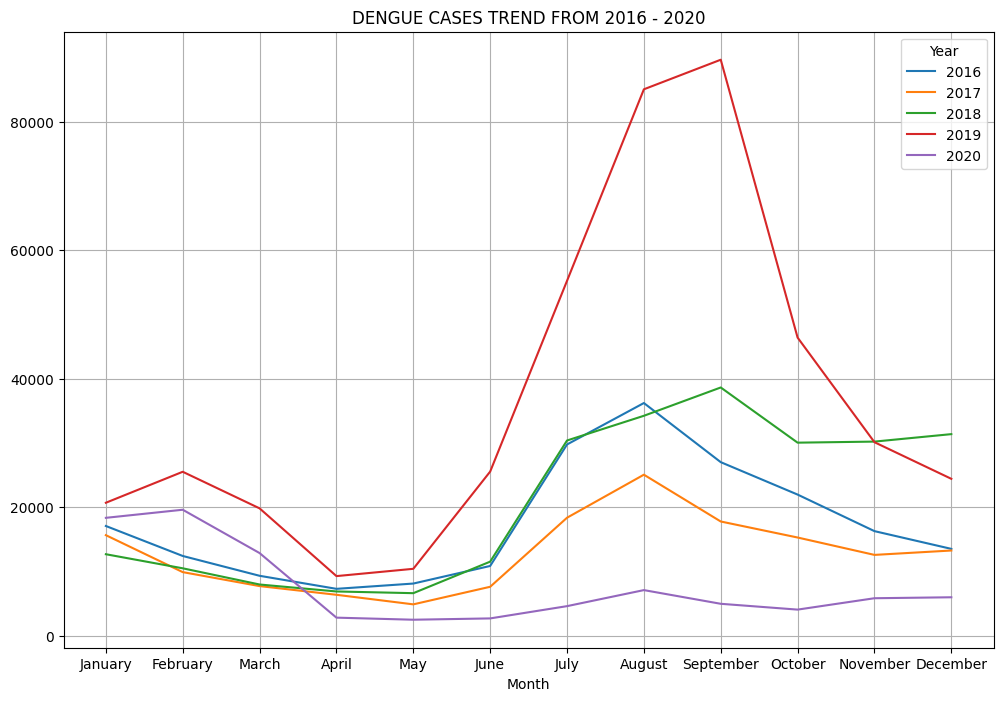

In [7]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)

monthly_cases = dengue.groupby(['Month', 'Year'])["Dengue_Cases"].sum()

monthly_cases.unstack().plot(kind='line')
plt.title('DENGUE CASES TREND FROM 2016 - 2020')
plt.gcf().set_size_inches(12,8)
plt.grid(True)
plt.xticks(range(0,12), month_order)
plt.show()

<h3>Insight 1:</h3>
Based on the line plot, Dengue cases usually occur in rainy months like July to September. This shows that dengue is more common when there is rain since this is when mosquitos breed.

<h3>Insight 2:</h3>
2019 had the highest number of dengue cases compared to other years. As shown in line plot, there was a huge spike in August which shows that August 2019 had a serious dengue outbreak in the country.

<h3>Insight 3:</h3>
In 2020, we can obviously notice that dengue cases had a big drop might be because of the COVID-19 Pandemic which made people stay at home and indoors.

<h1> ANALYSIS OF DENGUE CASES PER REGION </h1>

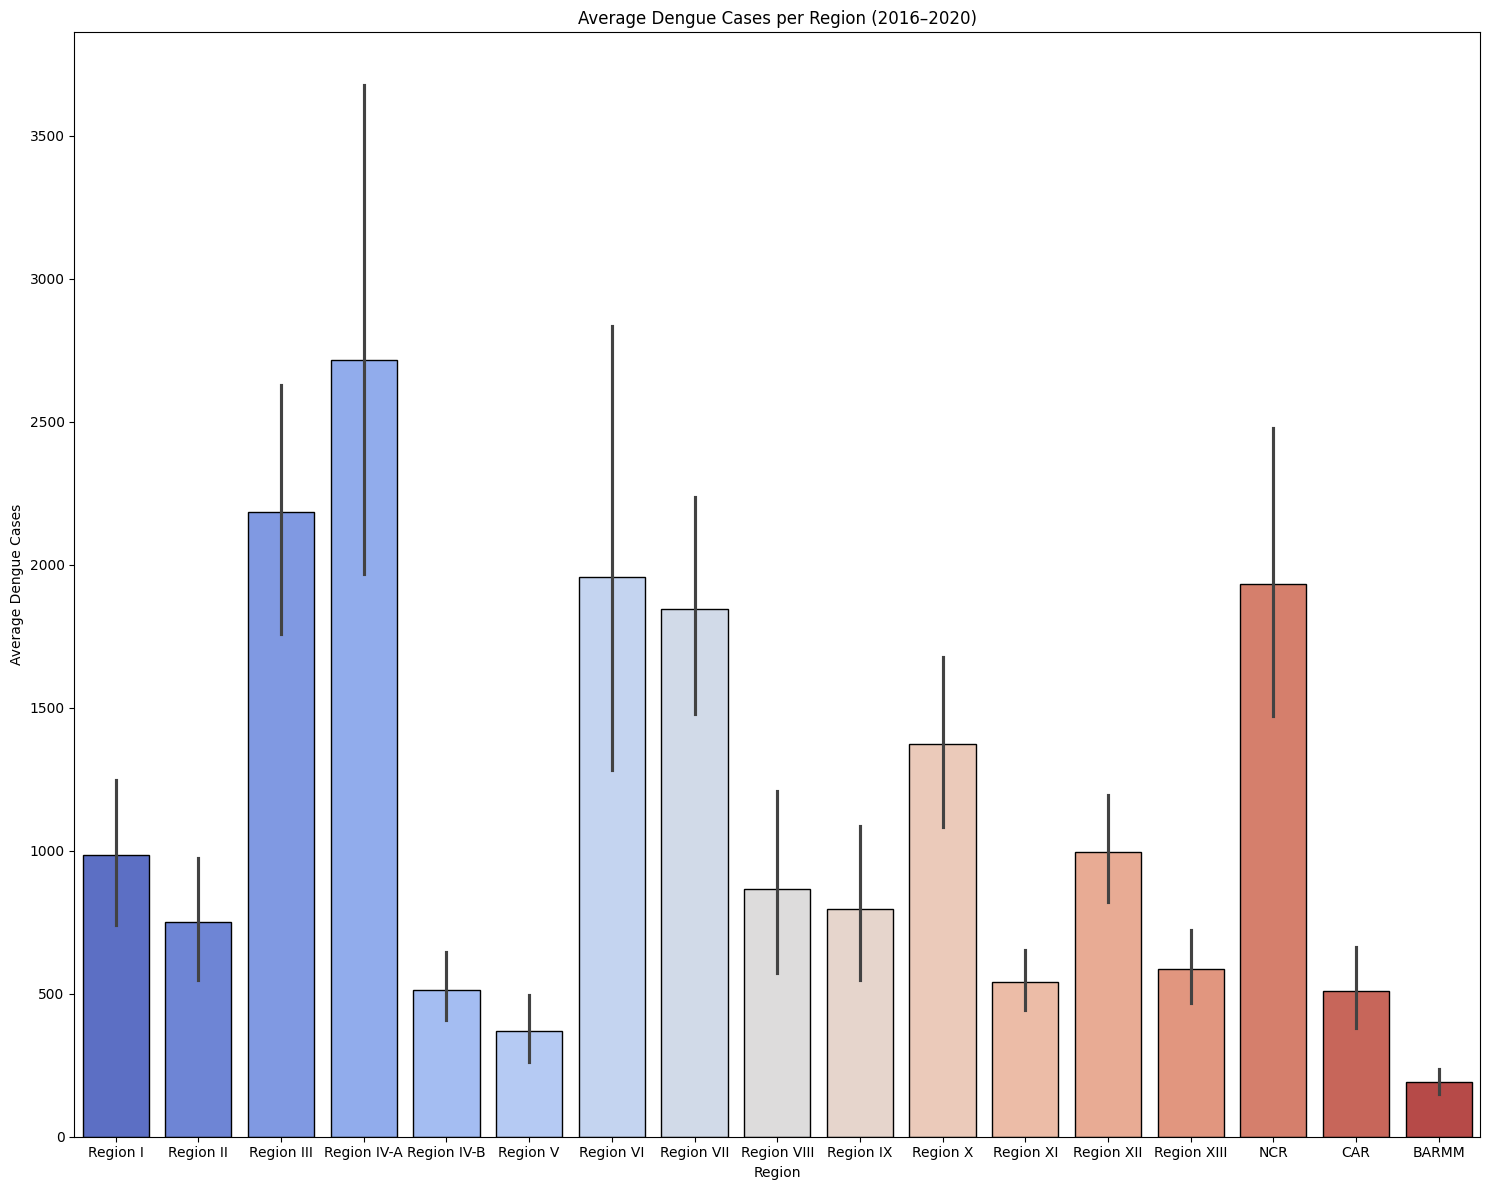

In [8]:
plt.figure(figsize=(15,12))

sns.barplot(
    data=dengue,
    x='Region',
    y='Dengue_Cases',
    palette='coolwarm',
    edgecolor='black'
)

plt.title("Average Dengue Cases per Region (2016–2020)")
plt.xlabel("Region")
plt.ylabel("Average Dengue Cases")

plt.tight_layout()
plt.show()

<h3>Insight 4:</h3>
Region 4-A got the most highest number of dengue cases among all regions. This shows that CALABARZON is the most affected area due to its population and communities where mosquitoes can easily breed.

<h3>Insight 5:</h3>
NCR (Manila), Region 3 (Central Luzon), and Region 6 (Western Visayas) also have high dengue cases. These regions are also highly populated which can contribute to the faster spread of dengue, especially in areas with poor waste management or clean water.

<h1>Mortality Rate per Year and per Region</h1>

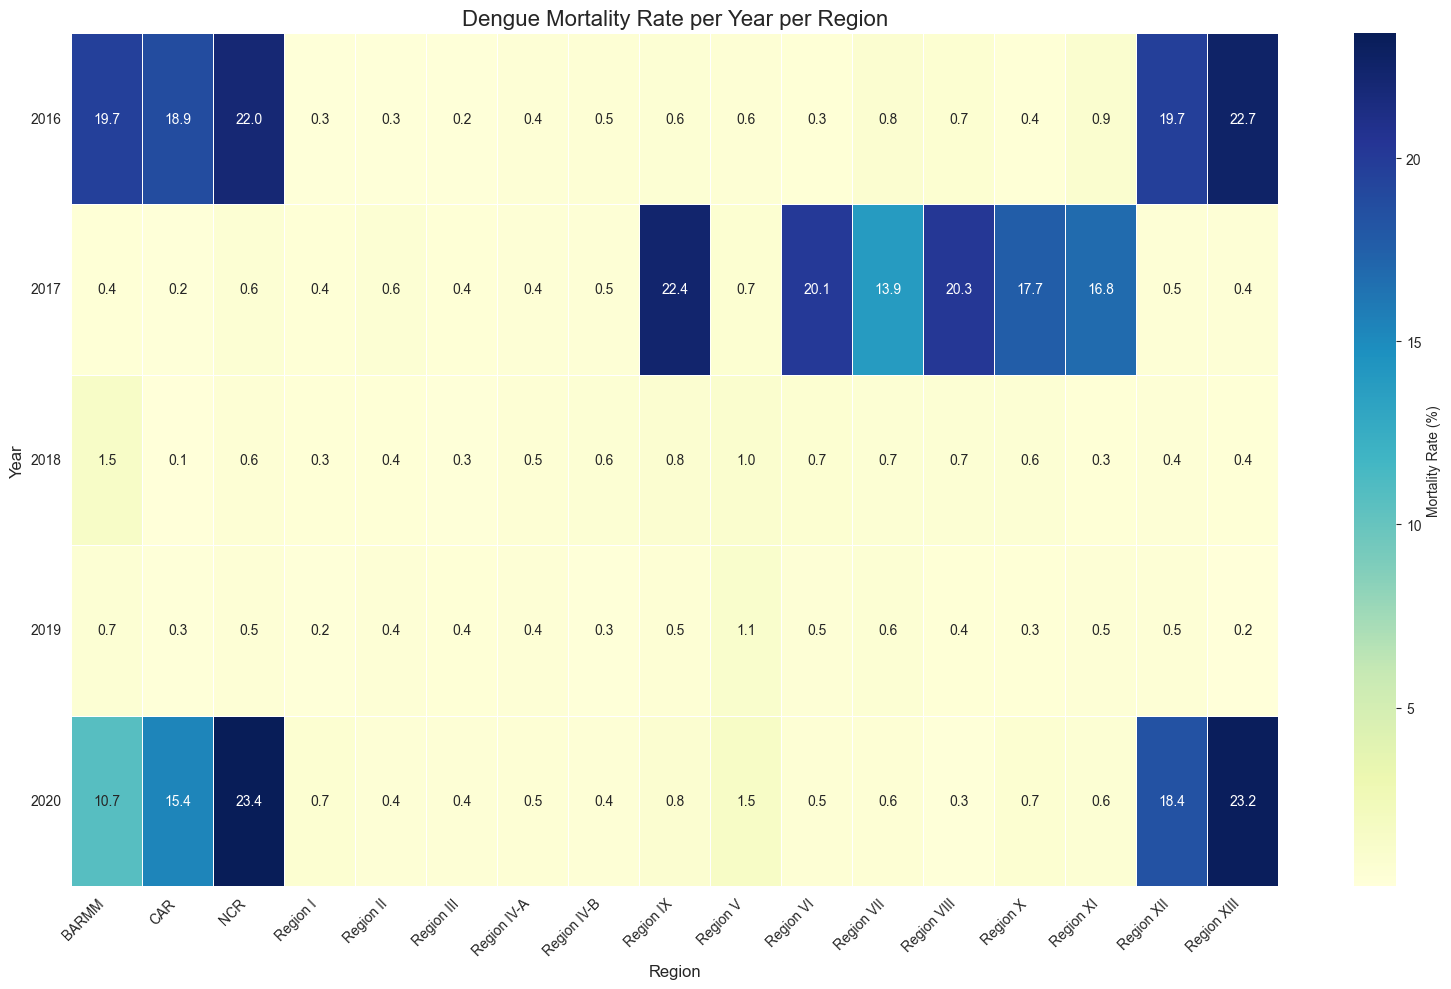

In [21]:
dengue['Mortality_Rate'] = (dengue['Dengue_Deaths'] / dengue['Dengue_Cases']) * 100

# Group by Year and Region and calculate the mean mortality rate
heatmap_data = dengue.groupby(['Year', 'Region'])['Mortality_Rate'].mean().unstack()

# Create the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Mortality Rate (%)'})
plt.title('Dengue Mortality Rate per Year per Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<h3>Insight 6:</h3>
2016 got the most recorded dengue mortality rates with regions such as NCR, Region 7 and Region 8 which means that dengue was more fatal in 2016 compared to the following years.

<h3>Insight 7:</h3>
There was a major decline in morality rates happened in 2017-2019. As shown above, most regions recorded very low mortality rates during these year, which means that there were better medical response, faster treament or improved health awareness.

<h1>Adding "Islands" in the dataset so we can extract some information</h1>

In [22]:
# Create a mapping of regions to island groups
island_map = {
    # Luzon
    'Region I': 'Luzon',
    'Region II': 'Luzon',
    'Region III': 'Luzon',
    'Region IV-A': 'Luzon',
    'Region IV-B': 'Luzon',
    'Region V': 'Luzon',
    'NCR': 'Luzon',
    'CAR': 'Luzon',

    # Visayas
    'Region VI': 'Visayas',
    'Region VII': 'Visayas',
    'Region VIII': 'Visayas',

    # Mindanao
    'Region IX': 'Mindanao',
    'Region X': 'Mindanao',
    'Region XI': 'Mindanao',
    'Region XII': 'Mindanao',
    'Region XIII': 'Mindanao',
    'BARMM': 'Mindanao'
}

dengue['Island'] = dengue['Region'].map(island_map)

In [23]:
dengue.dtypes

Month             category
Year                 int64
Region              object
Dengue_Cases         int64
Dengue_Deaths        int64
Mortality_Rate     float64
Island              object
dtype: object

In [24]:
# convert island to categorical type
dengue['Island'] = dengue['Island'].astype('category')

dengue.dtypes

Month             category
Year                 int64
Region              object
Dengue_Cases         int64
Dengue_Deaths        int64
Mortality_Rate     float64
Island            category
dtype: object

<h1>What island has the most total dengue cases?</h1>

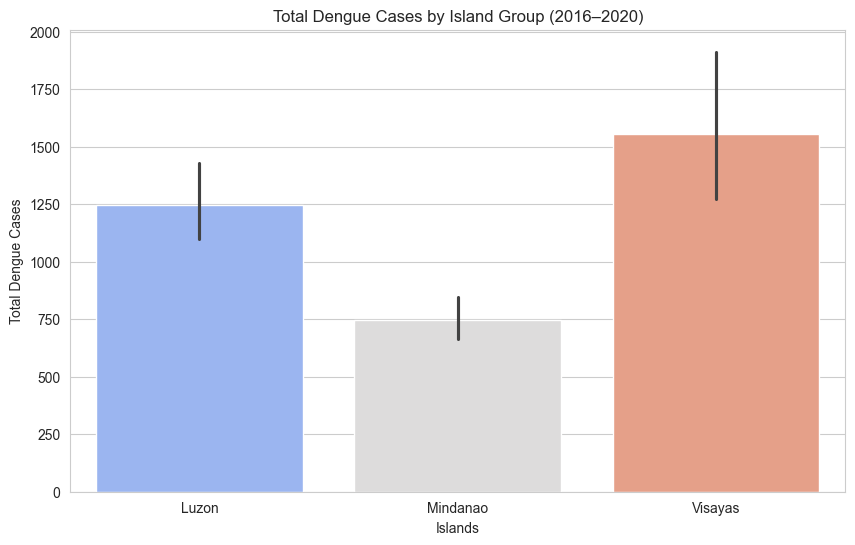

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(data=dengue, x='Island', y='Dengue_Cases', palette='coolwarm')

plt.title("Total Dengue Cases by Island Group (2016–2020)")
plt.xlabel("Islands")
plt.ylabel("Total Dengue Cases")
plt.show()

<h3>Insight 8:</h3>
Visayas got the most highest number of dengue cases. This means that dengue outbreaks are more common in Visayas possibly due to its climate and rainfall.

<h3>Insight 9:</h3>
Luzon ranks in second in total dengue cases even though its the most populated area compared to visayas, the total cases are slightly lower than Visayas which means that they have a better dengue control.

<h3>Insight 10:</h3>
Mindanao has the lowest number of dengue cases due to its large rural areas and its least populated cities, where dengue is least likely to be transmitted.